## Recall-Sheet

1. **Descriptive Parameter Estimates:**
   * **Sample Mean:** $$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x^i$$
   * **Unbiased Sample Variance:** $$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x^i - \bar{x})^2$$
   * **Mode ($x^*$):** The value that maximizes the probability density function:
     $$x^* = \arg\max_{x} f(x, \vec{p})$$

2. **Maximum Likelihood Estimation (MLE):**
   Given independently drawn samples $x^1, \dots, x^n$ and a hypothesized PDF $f(x, \vec{p})$, the Likelihood function is the product of the individual densities:
   $$L(\vec{p}) = \prod_{i=1}^{n} f(x^i, \vec{p})$$
   
   Because multiplying many small probabilities can cause numerical underflow in computer science, we maximize the **Log-Likelihood** instead:
   $$\ln L(\vec{p}) = \sum_{i=1}^{n} \ln f(x^i, \vec{p})$$

3. **Numerical MLE Optimization:**
   Most optimization packages are designed to minimize functions rather than maximize them. Therefore, in programming, we find the MLE parameters by minimizing the **Negative Log-Likelihood (NLL)**:
   $$\text{Minimize}_{\vec{p}} \quad -\ln L(\vec{p})$$

## Task 1: Estimating Mean, Variance, and Empirical Mode

We defined how to estimate descriptive parameters from a sample dataset $\{x^i\}$:
* **Sample Mean:** $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x^i$
* **Sample Variance (unbiased):** $\sigma^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x^i - \bar{x})^2$
* **Mode ($x^*$):** The value that maximizes the local probability density function ($x^* = \arg\max_x f(x, \vec{p})$).

**Your Goal:**
1. Generate a dataset of samples from a right-skewed Log-Normal distribution.
2. Calculate the sample mean and unbiased sample variance using standard NumPy operations.
3. Compute an empirical estimate of the **Mode** by finding the peak of a density-normalized histogram.
4. Plot the density histogram and overlay vertical lines for the **Mean**, **Mode**, and $e^{\mu}$ (the median). Notice how the heavy right tail pulls the physical mean far away from $e^{\mu}$!

--- Task 1 Solution ---
Estimated Mean:     5.1830
Estimated Variance: 7.6190
Estimated Mode:     3.4260


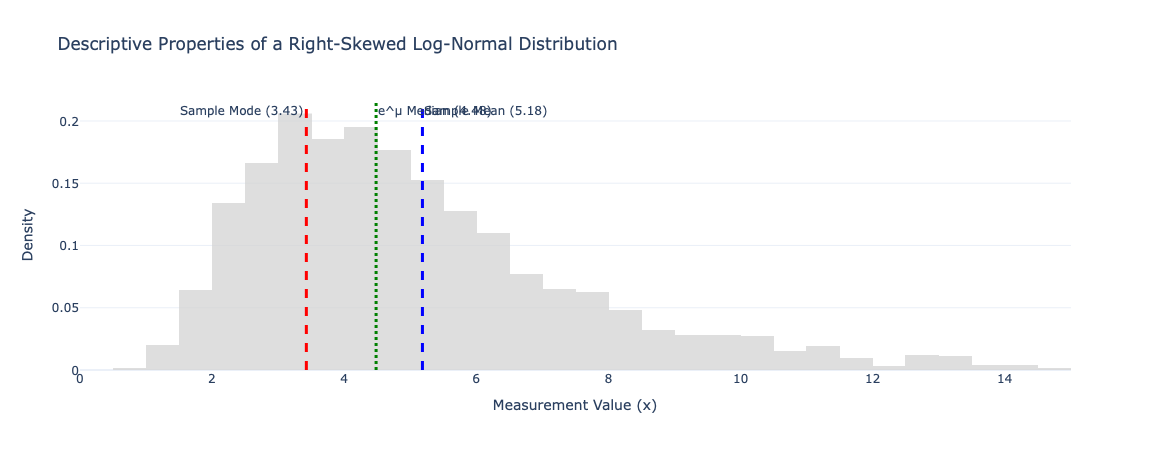

1.6453907019232343
4.4816890703380645


In [17]:
import numpy as np
import plotly.graph_objects as go

np.random.seed(42)
samples = np.random.lognormal(mean=1.5, sigma=0.5, size=2000)

# 1. Calculate Mean
x_bar = np.mean(samples)

# 2. Calculate Unbiased Variance (ddof=1 specifies dividing by n-1)
sigma_sq = np.var(samples, ddof=1)

# 3. Find Empirical Mode from Histogram peak
counts, bin_edges = np.histogram(samples, bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
max_bin_idx = np.argmax(counts)
x_star = bin_centers[max_bin_idx]

print("--- Task 1 Solution ---")
print(f"Estimated Mean:     {x_bar:.4f}")
print(f"Estimated Variance: {sigma_sq:.4f}")
print(f"Estimated Mode:     {x_star:.4f}")

# 4. Visualization
fig = go.Figure()

# Density Histogram of Data
fig.add_trace(
    go.Histogram(
        x=samples,
        histnorm="probability density",
        name="Log-Normal Samples",
        marker_color="lightgray",
        nbinsx=100,
        opacity=0.75,
    )
)

# Vertical lines showing properties
fig.add_vline(
    x=x_bar,
    line_color="blue",
    line_width=3,
    line_dash="dash",
    annotation_text=f"Sample Mean ({x_bar:.2f})",
    annotation_position="top right",
)

fig.add_vline(
    x=x_star,
    line_color="red",
    line_width=3,
    line_dash="dash",
    annotation_text=f"Sample Mode ({x_star:.2f})",
    annotation_position="top left",
)

fig.add_vline(
    x=np.exp(1.5),
    line_color="green",
    line_width=3,
    line_dash="dot",
    annotation_text=f"e^μ Median ({np.exp(1.5):.2f})",
    annotation_position="top right",
)

fig.update_layout(
    title="Descriptive Properties of a Right-Skewed Log-Normal Distribution",
    xaxis_title="Measurement Value (x)",
    yaxis_title="Density",
    template="plotly_white",
    height=450,
    xaxis=dict(range=[0, 15]),  # Zoom in to see the skew details clearly
)
fig.show()

print(np.log(x_bar))
print(np.exp(1.5))

---
## Task 2: Analytical vs. Numerical MLE (Exponential Distribution)

In **Example 5.4 and 5.5** of your textbook, we are given a simple 6-point dataset:
$$x = [1, 4, 7, 15, 21, 30]$$

For an Exponential distribution $f(x, \lambda) = \lambda e^{-\lambda x}$, the analytical MLE parameter is derived as:
$$\hat{\lambda} = \frac{n}{\sum_{i=1}^{n} x^i} = \frac{6}{78} \approx 0.0769$$

**Your Goal:**
1. Calculate the analytical parameter $\hat{\lambda}$ using a pythonic array operation.
2. Define an objective function representing the **Negative Log-Likelihood (NLL)** of the Exponential distribution.
3. Minimize this NLL using numerical optimization (`scipy.optimize.minimize`).
4. Plot the 6 data points along with your fitted Exponential distribution curve to verify the fit!

--- Task 2 Solution ---
Analytical Lambda: 0.0769
Numerical Lambda:  0.0769


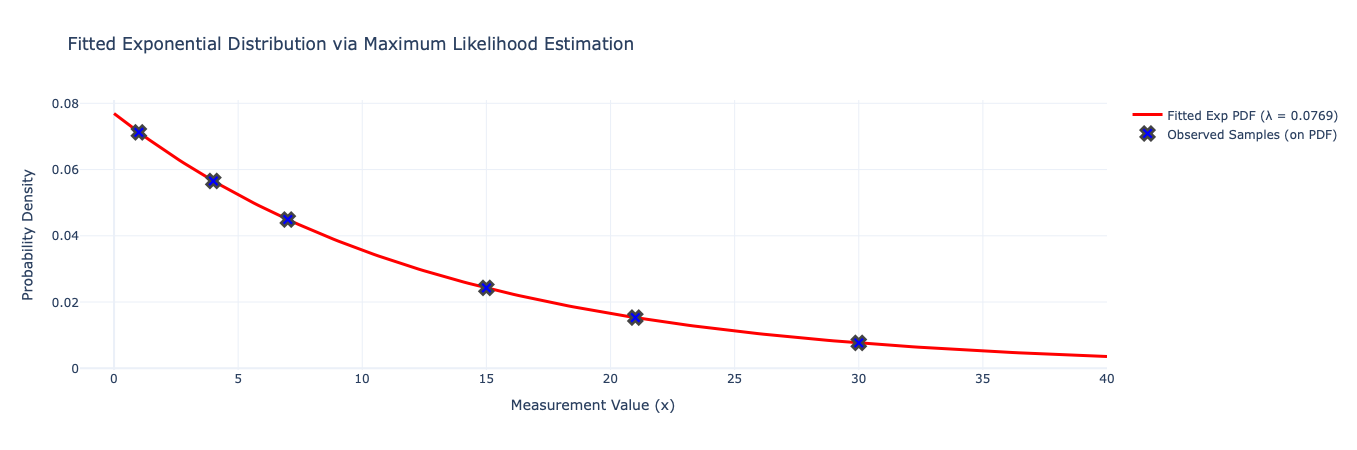

In [19]:
import numpy as np
import plotly.graph_objects as go
import scipy.optimize as optimize

x = np.array([1, 4, 7, 15, 21, 30])

# 1. Analytical Solution
# lambda_anal = len(x) / np.sum(x)
lambda_anal = 1 / np.mean(x)


# 2. Negative Log-Likelihood function
def neg_log_likelihood(lam):
    if lam <= 0:
        return 1e6
    log_pdf = np.log(lam) - lam * x
    return -np.sum(log_pdf)


# 3. Numerical Optimization
initial_guess = [0.5]
opt_result = optimize.minimize(neg_log_likelihood, initial_guess)
print(opt_result)
lambda_num = opt_result.x[0]

print("--- Task 2 Solution ---")
print(f"Analytical Lambda: {lambda_anal:.4f}")
print(f"Numerical Lambda:  {lambda_num:.4f}")

# 4. Plotting the Fit
x_curve = np.linspace(0, 40, 200)
y_curve = lambda_num * np.exp(-lambda_num * x_curve)

# Calculate the exact PDF height for each sample point to place them on the curve
y_samples = lambda_num * np.exp(-lambda_num * x)

fig = go.Figure()

# Fitted PDF curve (Correction: Explicitly defined x=x_curve and y=y_curve)
fig.add_trace(
    go.Scatter(
        x=x_curve,
        y=y_curve,
        mode="lines",
        name=f"Fitted Exp PDF (λ = {lambda_num:.4f})",
        line=dict(color="red", width=3),
    )
)

# Observed data points plotted directly ON the curve (Correction: Explicitly defined x=x and y=y_samples)
fig.add_trace(
    go.Scatter(
        x=x,
        y=y_samples,
        mode="markers",
        name="Observed Samples (on PDF)",
        marker=dict(color="blue", size=12, symbol="x", line=dict(width=2.5)),
    )
)

fig.update_layout(
    title="Fitted Exponential Distribution via Maximum Likelihood Estimation",
    xaxis_title="Measurement Value (x)",
    yaxis_title="Probability Density",
    template="plotly_white",
    height=450,
)
fig.show()

---
## Task 3: Evaluating Distribution Hypotheses (Recreating Example 5.6)

In your textbook's **Example 5.6**, we have 10 data points:
$$x = [3.09, 4.95, 4.73, 1.21, 2.27, 2.71, 2.7, 3.03, 2.97, 2.1]$$

We want to fit two different candidate models using MLE:
1. **Normal Distribution Model ($\mathcal{N}(\mu, \sigma^2)$):**
   * **Note:** The derivative of the Gaussian Likelihood function yields the standard sample mean $\hat{\mu} = \bar{x}$, but the standard deviation estimate is **biased** (using $n$ in the denominator instead of $n-1$):
     $$\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (x^i - \hat{\mu})^2$$
2. **Log-Normal Distribution Model:**
   * Calculated by taking $y = \ln x$, fitting a standard Normal distribution to $y$, and mapping the parameters back.

**Your Goal:**
Calculate the MLE parameters for both Normal and Log-Normal models using standard estimators, plot the fitted PDF curves over the dataset's normalized histogram, and determine which model represents the true distribution.

--- Task 3 Fit Parameters ---
Normal Fit:    mu = 2.976, sigma = 1.073
Lognormal Fit: mu = 1.022, sigma = 0.381


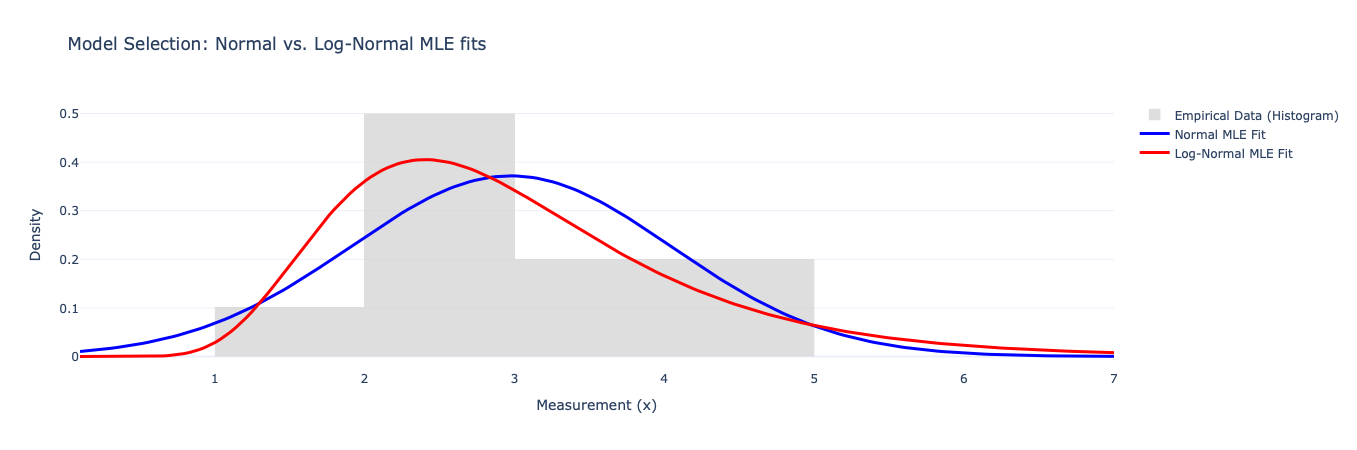

In [3]:
import numpy as np
import plotly.graph_objects as go
import scipy.stats as stats

x = np.array([3.09, 4.95, 4.73, 1.21, 2.27, 2.71, 2.7, 3.03, 2.97, 2.1])

# 1. Normal MLE (Biased standard deviation estimator)
mu_norm = np.mean(x)
sigma_norm = np.std(x, ddof=0)  # ddof=0 gives the 1/n standard deviation divisor

# 2. Log-Normal MLE via log transformation
y = np.log(x)
mu_log = np.mean(y)
sigma_log = np.std(y, ddof=0)

print("--- Task 3 Fit Parameters ---")
print(f"Normal Fit:    mu = {mu_norm:.3f}, sigma = {sigma_norm:.3f}")
print(f"Lognormal Fit: mu = {mu_log:.3f}, sigma = {sigma_log:.3f}")

# 3. Generating Plot
x_plot = np.linspace(0.1, 7.0, 200)
pdf_norm = stats.norm.pdf(x_plot, loc=mu_norm, scale=sigma_norm)
pdf_lognorm = stats.lognorm.pdf(x_plot, s=sigma_log, scale=np.exp(mu_log))

fig = go.Figure()
# Density Histogram
fig.add_trace(
    go.Histogram(
        x=x,
        histnorm="probability density",
        name="Empirical Data (Histogram)",
        nbinsx=6,
        marker_color="lightgray",
        opacity=0.75,
    )
)
# Normal Fit line
fig.add_trace(
    go.Scatter(
        x=x_plot,
        y=pdf_norm,
        mode="lines",
        name="Normal MLE Fit",
        line=dict(color="blue", width=3),
    )
)
# Log-Normal Fit line
fig.add_trace(
    go.Scatter(
        x=x_plot,
        y=pdf_lognorm,
        mode="lines",
        name="Log-Normal MLE Fit",
        line=dict(color="red", width=3),
    )
)

fig.update_layout(
    title="Model Selection: Normal vs. Log-Normal MLE fits",
    xaxis_title="Measurement (x)",
    yaxis_title="Density",
    template="plotly_white",
    height=450,
)
fig.show()

---
## 💡 Optional Visual Aid: Dynamic Parameter Fitting

*Note: This section is purely an interactive visualization to help you build intuition! It is not tested on the final exam.*

In Maximum Likelihood Estimation, we optimize the model parameters to make our observed data "as likely as possible." 

Below is an interactive dashboard analyzing an asymmetric **Log-Normal distribution**.
* The **top wide plot** illustrates the skewed PDF. 
* The **bottom plots** show the Q-Q and P-P plots dynamically adapting. 

**Your Goal:**
1. Use the **Shape ($s$)** and **Scale** sliders to change the model properties.
2. Select the number of **Quantiles ($k$)** to observe how $k$-quantiles split the distribution into exactly $k$ regions using exactly $k-1$ green dashed lines.
3. Align the scattered blue and red points perfectly with the $y=x$ reference diagonals!

In [4]:
import ipywidgets as widgets
import numpy as np
import plotly.graph_objects as go
import scipy.stats as stats
from IPython.display import display
from plotly.subplots import make_subplots

# 1. Generate a "perfect" hidden dataset using an asymmetric Log-Normal distribution
np.random.seed(42)
hidden_s = 0.5  # Shape parameter (controls skewness/asymmetry)
hidden_scale = 6.0  # Scale parameter (controls stretch)
x_nice = stats.lognorm.rvs(s=hidden_s, scale=hidden_scale, size=100)
x_nice_sorted = np.sort(x_nice)

# 2. UI Elements
s_slider = widgets.FloatSlider(
    value=0.2,
    min=0.1,
    max=1.5,
    step=0.05,
    description="Shape (s):",
    continuous_update=False,
    layout=widgets.Layout(width="300px"),
)
scale_slider = widgets.FloatSlider(
    value=2.0,
    min=1.0,
    max=12.0,
    step=0.2,
    description="Scale:",
    continuous_update=False,
    layout=widgets.Layout(width="300px"),
)
k_slider = widgets.IntSlider(
    value=5,
    min=2,
    max=10,
    description="Quantiles (k):",
    continuous_update=False,
    layout=widgets.Layout(width="300px"),
)


# 3. Dynamic Plotting Function
def plot_interactive(s, scale, k):
    # k-quantiles divide the distribution into k regions using k-1 cut points
    probs = np.arange(1, k) / k
    q_vals = stats.lognorm.ppf(probs, s, scale=scale)

    # Extract sample quantiles based on the (k-1) cut points
    indices = [int(len(x_nice) * i / k) for i in range(1, k)]
    sample_q = x_nice_sorted[indices]

    # P-P Plot data: Theoretical CDF evaluated at the sample quantiles
    t_prob = stats.lognorm.cdf(sample_q, s, scale=scale)

    # Create a 2-row layout: Row 1 is wide (colspan=2), Row 2 contains side-by-side plots
    fig = make_subplots(
        rows=2,
        cols=2,
        specs=[[{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            f"PDF with Quantiles ({k}-Quantiles split into {k} regions)",
            "Q-Q Plot",
            "P-P Plot",
        ),
        vertical_spacing=0.15,
    )

    # Row 1: PDF Plot (Asymmetric, starting at 0)
    x_range = np.linspace(0.01, 20.0, 300)
    pdf_vals = stats.lognorm.pdf(x_range, s, scale=scale)
    fig.add_trace(
        go.Scatter(
            x=x_range, y=pdf_vals, mode="lines", name="PDF", line=dict(color="gray")
        ),
        row=1,
        col=1,
    )

    # Add vertical quantile lines on the PDF (exactly k-1 lines)
    for q in q_vals:
        fig.add_vline(x=q, line_dash="dash", line_color="green", row=1, col=1)

    # Row 2, Col 1: Q-Q Plot
    fig.add_trace(
        go.Scatter(
            x=q_vals, y=sample_q, mode="markers", marker=dict(color="blue"), name="Q-Q"
        ),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=[0, 20],
            y=[0, 20],
            mode="lines",
            line=dict(color="black", dash="dash"),
            showlegend=False,
        ),
        row=2,
        col=1,
    )

    # Row 2, Col 2: P-P Plot
    fig.add_trace(
        go.Scatter(
            x=probs, y=t_prob, mode="markers", marker=dict(color="red"), name="P-P"
        ),
        row=2,
        col=2,
    )
    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode="lines",
            line=dict(color="black", dash="dash"),
            showlegend=False,
        ),
        row=2,
        col=2,
    )

    # Layout modifications & Locked bounds to prevent jumping
    fig.update_layout(
        height=700,
        width=1000,
        title_text=f"Asymmetric Log-Normal Fitting (Current: s={s:.2f}, scale={scale:.1f}, {k}-quantiles)",
        template="plotly_white",
        showlegend=False,
    )

    # Lock axes
    fig.update_xaxes(title_text="Value (x)", range=[0, 20], row=1, col=1)
    fig.update_yaxes(title_text="Density", row=1, col=1)

    fig.update_xaxes(title_text="Theoretical Quantiles", range=[0, 20], row=2, col=1)
    fig.update_yaxes(title_text="Sample Quantiles", range=[0, 20], row=2, col=1)

    fig.update_xaxes(title_text="Observed Probability", range=[0, 1], row=2, col=2)
    fig.update_yaxes(title_text="Theoretical Probability", range=[0, 1], row=2, col=2)

    fig.show()


# 4. Bind UI
out = widgets.interactive_output(
    plot_interactive, {"s": s_slider, "scale": scale_slider, "k": k_slider}
)
display(widgets.HBox([s_slider, scale_slider, k_slider]), out)

Output()